Today's topics:
* correlation and the Pearson `r`
* fitting a line with `scipy.stats.linregress`
* interpreting slope, intercept and predictions

# The gap between yielding and fracture

A titanium hip stem that yields has already failed.
A permanent bend in an implant means revision surgery, not a part that keeps doing its job a little worse.

So an implant designer watches the gap between the stress where an alloy starts to deform permanently and the stress where it breaks.

Call that gap the margin: more margin means more warning before fracture.

<img src="https://upload.wikimedia.org/wikipedia/commons/6/6f/Al_tensile_test.jpg" alt="An aluminum alloy tensile specimen broken in two, with visible necking near the break and a cup and cone fracture surface" width=520/>

A tensile specimen taken to fracture.
Photo by Sigmund, [CC BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/), [via Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Al_tensile_test.jpg).

The narrowing near the break is the permanent deformation, and it started long before the specimen came apart.

Two alloys with very different yield strengths, and almost the same margin between yield and fracture.
Today we ask whether that holds across a whole compilation of alloys, and the tool for asking is a fitted line.

# The table

We met this compilation of titanium implant alloys in L05, when we looked at the spread of yield strengths across 283 alloys.
([Salvador et al., *Scientific Data* 9, 188](https://doi.org/10.1038/s41597-022-01283-9), CC BY 4.0.)

We return to it with a new question: given an alloy's yield strength, what is its ultimate tensile strength likely to be?

In [1]:
#@title Load the Ti-alloy dataset (click ▶ to run, data loading, not a learning objective) { display-mode: "form" }
import os

import pandas as pd


def _find(name):
    return next(
        (p for p in (f'datasets/{name}', f'../datasets/{name}', f'../../datasets/{name}',
                     f'../../../datasets/{name}')
         if os.path.exists(p)),
        f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{name}',
    )


try:
    data = pd.read_csv(_find('biomaterials_ti_alloys.csv'))
except Exception as e:
    raise RuntimeError(
        "Could not load the Ti-alloy data. If you are in Colab, check your "
        "internet connection."
    ) from e

print(f'Loaded {len(data)} titanium alloys')
data[['eid', 'YS_MPa', 'UTS_MPa']].head()

Loaded 283 titanium alloys


,eid,YS_MPa,UTS_MPa
0,Ti-23Nb-10Zr-2.0Fe,782.0,NaN
1,Ti-27Nb-10Zr-1.5Fe,735.0,NaN
2,Ti-31Nb-10Zr-1.0Fe,672.0,NaN
3,Ti-11Nb-7Zr-3.5Fe,1011.0,NaN
4,Ti-19Nb-6Sn-2.5Fe,765.0,NaN


In [2]:
display(data.head())
print(data.shape)

,eid,Al_frac,Cr_frac,Cu_frac,Fe_frac,Hf_frac,Mn_frac,Mo_frac,Nb_frac,Ni_frac,...,DAR_pct,DAR_err,test_mode,HV,HV_err,Mo_equivalent,Mo_equivalent_class,ref_doi,ref_key,comments
0,Ti-23Nb-10Zr-2.0Fe,0.0,0.0,0.0,0.023400,0.0,0.0,0.0,0.135800,0.0,...,10.0,1.0,tension,252.0,8.0,12.88,meta,10.1007/s10853-021-06002-0,salvador2021,Young modulus obtained via tensile tests (Tabl...
1,Ti-27Nb-10Zr-1.5Fe,0.0,0.0,0.0,0.015600,0.0,0.0,0.0,0.163200,0.0,...,9.0,1.0,tension,229.0,2.0,11.65,meta,10.1007/s10853-021-06002-0,salvador2021,Young modulus obtained via tensile tests (Tabl...
2,Ti-31Nb-10Zr-1.0Fe,0.0,0.0,0.0,0.013801,0.0,0.0,0.0,0.189919,0.0,...,15.0,6.0,tension,218.0,5.0,12.08,meta,10.1007/s10853-021-06002-0,salvador2021,Young modulus obtained via tensile tests (Tabl...
3,Ti-11Nb-7Zr-3.5Fe,0.0,0.0,0.0,0.034903,0.0,0.0,0.0,0.061806,0.0,...,4.0,1.0,tension,358.0,3.0,13.78,meta,10.1016/j.matdes.2018.10.040,dalbo2018,Young modulus obtained via tensile tests (Tabl...
4,Ti-19Nb-6Sn-2.5Fe,0.0,0.0,0.0,0.025600,0.0,0.0,0.0,0.110000,0.0,...,31.0,5.0,tension,260.0,9.0,12.76,meta,10.1016/j.matdes.2018.10.040,dalbo2018,Young modulus obtained via tensile tests (Tabl...


(283, 43)


## Keeping the rows with both properties

Not every study reported both properties, and `NaN` marks the missing measurements.
`.dropna` keeps the rows that carry a value in every column we name.

In [3]:
both = data.dropna(subset=['YS_MPa', 'UTS_MPa'])
print(f'{len(both)} of {len(data)} alloys report both properties')

x = both['YS_MPa']
y = both['UTS_MPa']

190 of 283 alloys report both properties


# Looking at the pair first

Start with the figure before reducing the relationship to one number.

Text(0, 0.5, 'ultimate tensile strength (MPa)')

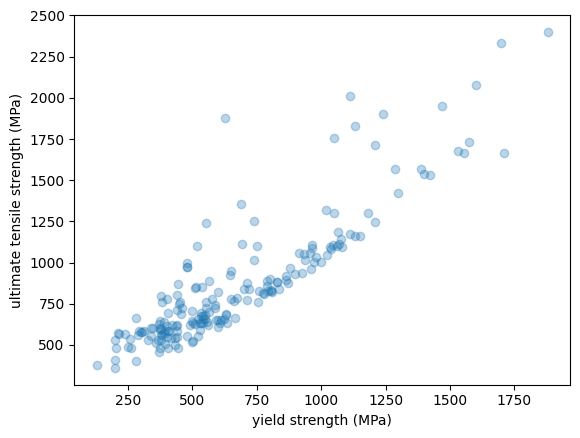

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.scatter(x, y, alpha=0.3)
ax.set_xlabel('yield strength (MPa)')
ax.set_ylabel('ultimate tensile strength (MPa)')

The cloud rises to the right, so alloys with a high yield strength tend to have a high tensile strength.
The points sit in a band rather than on a line, which is what we would expect from a hundred different studies.

# Correlation

"Rises to the right" is a description, not a measurement.
The **Pearson correlation coefficient**, written `r`, puts one number on how close a cloud of points comes to a straight line.

In [5]:
from scipy import stats

correlation = stats.pearsonr(x, y)
print(f'r = {correlation.statistic:.3f}')

r = 0.882


`r` runs from -1 to +1.

Its sign gives the direction, while its distance from zero measures the strength of the linear relationship.
A value of 1 or -1 puts every point on a line; a value near 0 means there is little linear pattern, although a curved relationship could still be present.

0.882 is a strong positive relationship, and the width of the band is why it is not closer to 1.

## What `r` does not say

A large `r` says the two columns move together, not that one causes the other.

Chemistry, processing and microstructure can affect both properties, so a third factor can move them together.

An `r` this size is a reason to go looking for a mechanism rather than a substitute for finding one.

### [Check your understanding]

`DAR_pct` is the deformation at rupture, how far a specimen stretched before it broke, as a percentage.

1. Build a table called `ductile` holding the rows where `YS_MPa` and `DAR_pct` are both reported, using `.dropna` with those two column names.
2. Print how many alloys that leaves.
3. Make a `fig, ax` scatter of `DAR_pct` against `YS_MPa`.
4. Label both axes.
5. Compute the Pearson `r` with `stats.pearsonr`, then print the result's `.statistic` field.
6. In a comment, give the sign and the size of that `r`, and what the sign means for someone choosing an alloy.

*Nothing in that number says which way any causation runs, or whether there is any.*

# Fitting a line

`r` describes how closely the points follow a line, but not the line's slope or intercept.
`stats.linregress` fits `y = m*x + b` by least squares and returns an object with named fields.
Least squares chooses the line with the smallest total squared vertical gaps from the data.

In [6]:
fit = stats.linregress(x, y)

print(f'slope     = {fit.slope:.3f}')
print(f'intercept = {fit.intercept:.1f} MPa')
print(f'r         = {fit.rvalue:.3f}')

slope     = 0.985
intercept = 204.3 MPa
r         = 0.882


`fit.rvalue` is the same 0.882 stored in `correlation.statistic`.
The fit carries it because the correlation and the line are two answers to one question about these columns.

## Drawing the fitted line

Two x values are enough to draw a straight line, so take the smallest and largest yield strength and put them through the equation.

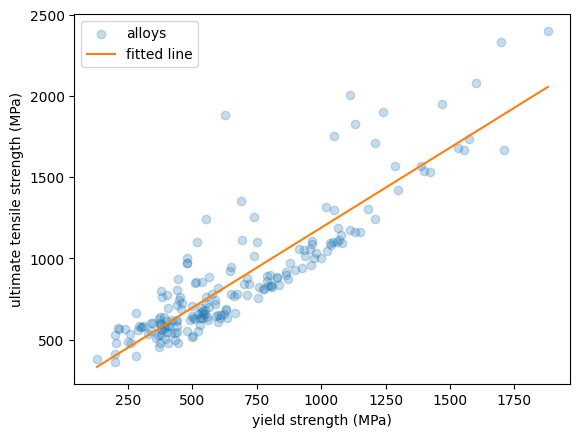

In [7]:
import numpy as np

xx = np.array([np.min(x), np.max(x)])
yy = fit.slope * xx + fit.intercept

fig, ax = plt.subplots()
ax.scatter(x, y, alpha=0.25, label='alloys')
ax.plot(xx, yy, color='C1', label='fitted line')
ax.set_xlabel('yield strength (MPa)')
ax.set_ylabel('ultimate tensile strength (MPa)')
ax.legend()

# Reading the fitted equation

The fitted line is `UTS = 0.985 * YS + 204`.
Because both axes use MPa, the slope means 0.985 MPa of predicted tensile strength per 1 MPa of yield strength.
The intercept is the model's predicted tensile strength at zero yield strength, which lies outside the measured range and has no direct implant interpretation.
Since the slope is close to 1, the predicted gap between tensile and yield strength changes only slowly across the data.

One number for the whole compilation hides how much the alloys differ.

In [8]:
margin = y - x

print(f'smallest margin: {np.min(margin):.0f} MPa')
print(f'mean margin:     {np.mean(margin):.0f} MPa')
print(f'median margin:   {np.median(margin):.0f} MPa')
print(f'largest margin:  {np.max(margin):.0f} MPa')

smallest margin: -45 MPa
mean margin:     194 MPa
median margin:   143 MPa
largest margin:  1254 MPa


The measured margins average 194 MPa, but they range from below zero to more than 1200 MPa.
A designer choosing one alloy for one implant needs that alloy's own two measurements, not the average relationship.

# Prediction, inside and outside the data

Substituting a yield strength into the fitted equation gives a predicted tensile strength.

In [9]:
pred_800 = fit.slope * 800 + fit.intercept
print(f'800 MPa yield strength predicts {pred_800:.0f} MPa tensile strength')
print(f'predicted margin: {pred_800 - 800:.0f} MPa')

800 MPa yield strength predicts 992 MPa tensile strength
predicted margin: 192 MPa


The alloys this line was fit on run from 130 to 1880 MPa of yield strength, so 800 sits well inside them.
A prediction inside the fitted range is **interpolation**, and the surrounding data is what supports it.

In [10]:
print(f'{np.min(x):.0f} to {np.max(x):.0f} MPa of yield strength in the fitted alloys')

pred_2500 = fit.slope * 2500 + fit.intercept
print(f'2500 MPa yield strength predicts {pred_2500:.0f} MPa tensile strength')

130 to 1880 MPa of yield strength in the fitted alloys
2500 MPa yield strength predicts 2666 MPa tensile strength


2500 MPa is beyond every alloy in the table, which makes that second number **extrapolation**.

Python computed it without complaint, because the arithmetic does not know where the data stopped.
Nothing in this compilation says the relationship holds its slope out there.

# Summary

* The Pearson `r` measures how close two columns come to a straight line, from -1 to +1.
* The sign of `r` is the direction and its size is the strength.
* A large `r` does not establish that one property causes the other.
* `stats.linregress` returns the fitted line as `slope`, `intercept` and `rvalue`.
* A slope carries units of y per x; an intercept carries the units of y and describes the model at x equal to zero.
* Interpolation predicts inside the fitted range, and extrapolation runs the same arithmetic where no data supports it.

Across 190 titanium-alloy records, tensile strength rises about 0.985 MPa for each additional MPa of yield strength.
At 800 MPa yield strength, the line predicts a margin near 192 MPa; the measured margins vary widely from alloy to alloy.

## Further reading

- Salvador, C. A. F. et al. "A compilation of experimental data on the mechanical properties and microstructural features of Ti-alloys." *Scientific Data* 9, 188 (2022). https://doi.org/10.1038/s41597-022-01283-9
- [SciPy documentation: `scipy.stats.pearsonr`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html)
- [SciPy documentation: `scipy.stats.linregress`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.linregress.html)